In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def analyze_data_stats_by_split(root_dir):
    """
    Analyzes dataset to count patients and images by split (train, valid, test) and category (good, Ungood),
    while ignoring files in 'label' subfolders.

    Args:
        root_dir (str): The root directory of the dataset.

    Returns:
        pd.DataFrame: A DataFrame with the counts and percentages for each split and category.
    """
    all_image_data = []

    splits = ['train', 'valid', 'test']
    categories = ['good', 'Ungood']
    
    for split in splits:
        for category in categories:
            category_path = os.path.join(root_dir, split, category)
            
            if os.path.exists(category_path):
                for dirpath, dirnames, filenames in os.walk(category_path):
                    if 'label' in dirpath.lower().split(os.path.sep) or 'bodymask' in dirpath.lower().split(os.path.sep):
                        continue
                    
                    for filename in filenames:
                        if filename.lower().endswith('.nii') or filename.lower().endswith('.png'):
                            patient_id = filename.split('_')[0]
                            all_image_data.append({
                                'split': split,
                                'category': category,
                                'patient_id': patient_id
                            })

    if not all_image_data:
        print("No image data found in the specified directory structure. Please check your path and file structure.")
        return None

    df = pd.DataFrame(all_image_data)
    total_patients = df['patient_id'].nunique()
    total_slices = len(df)
    
    grouped_stats = df.groupby(['split', 'category']).agg(
        num_patients=pd.NamedAgg(column='patient_id', aggfunc='nunique'),
        num_slices=pd.NamedAgg(column='patient_id', aggfunc='count')
    ).reset_index()

    if total_patients > 0:
        grouped_stats['Percentage Patients'] = (grouped_stats['num_patients'] / total_patients) * 100
    else:
        grouped_stats['Percentage Patients'] = 0.0

    if total_slices > 0:
        grouped_stats['Percentage Slices'] = (grouped_stats['num_slices'] / total_slices) * 100
    else:
        grouped_stats['Percentage Slices'] = 0.0

    grouped_stats.rename(columns={
        'num_patients': 'Total Patients',
        'num_slices': 'Total Slices (Images)'
    }, inplace=True)
    
    return grouped_stats

In [7]:
def plot_stats(stats_df):
    """
    Generates bar charts for patient and image counts with values displayed on the bars.
    """
    if stats_df is None:
        return
    
    stats_df['label'] = stats_df['split'] + '/' + stats_df['category']
    stats_df = stats_df.sort_values('Total Patients', ascending=False)

    # Plot Total Patients
    plt.figure(figsize=(10, 6))
    bars = plt.bar(stats_df['label'], stats_df['Total Patients'], color='skyblue')
    plt.title('Patient Count by Dataset Partition')
    plt.xlabel('Data Subset')
    plt.ylabel('Number of Patients')
    plt.xticks(rotation=45, ha='right')
    
    # Add number labels on top of the bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    #plt.savefig('total_patients_bar_chart.png')
    plt.show()

    # Plot Total Slices (Images)
    plt.figure(figsize=(10, 6))
    bars = plt.bar(stats_df['label'], stats_df['Total Slices (Images)'], color='skyblue')
    plt.title('Number of Slices (Images) by Data Subset')
    plt.xlabel('Data Subset')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    
    # Add number labels on top of the bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    #plt.savefig('total_slices_bar_chart.png')
    plt.show()

Detailed Dataset Statistics:
split category  Total Patients  Total Slices (Images)  Percentage Patients  Percentage Slices
 test   Ungood              14                    415            13.861386           5.426255
 test     good              16                   1320            15.841584          17.259414
train     good              60                   5262            59.405941          68.802301
valid   Ungood               3                     20             2.970297           0.261506
valid     good               8                    631             7.920792           8.250523


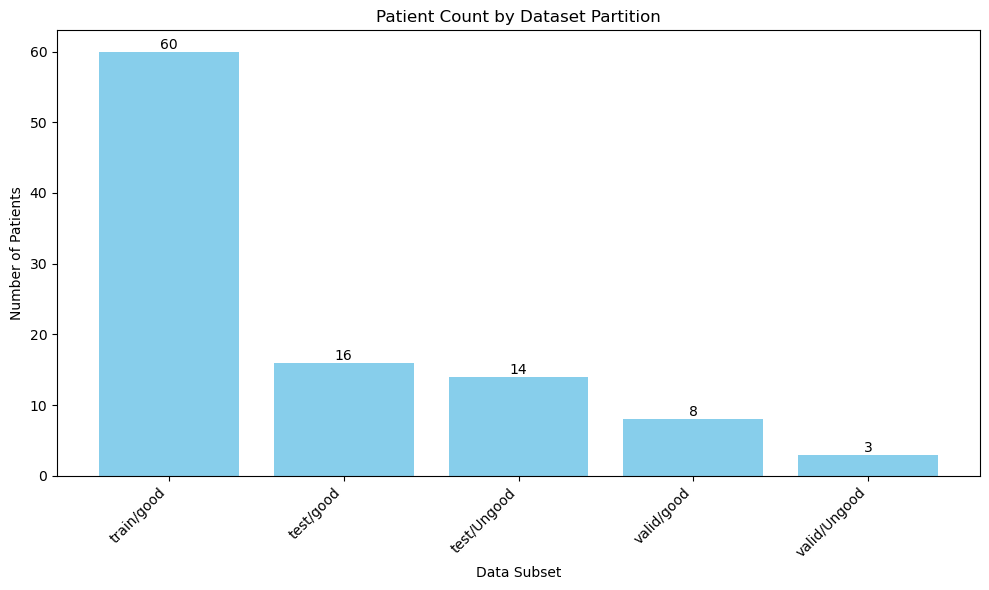

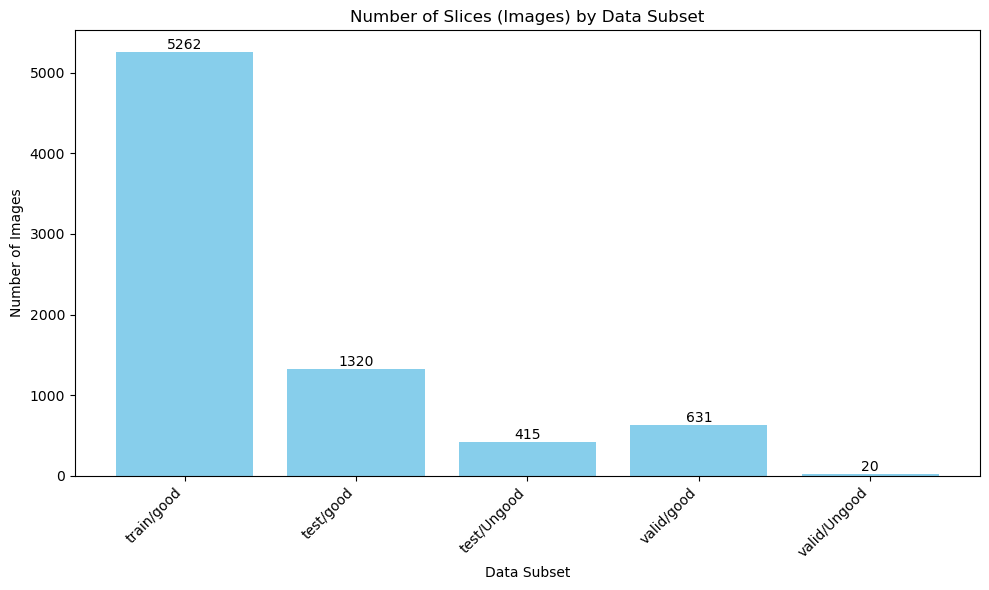

In [4]:
# Define the root directory of your dataset
dataset_path = r'C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\dataset\synth23_pelvis_v7_nifti_con'

# Run the data analysis and plotting functions
stats_df = analyze_data_stats_by_split(dataset_path)

if stats_df is not None:
    print("Detailed Dataset Statistics:")
    print(stats_df[['split', 'category', 'Total Patients', 'Total Slices (Images)', 'Percentage Patients', 'Percentage Slices']].to_string(index=False))
    plot_stats(stats_df)

Detailed Dataset Statistics:
split category  Total Patients  Total Slices (Images)  Percentage Patients  Percentage Slices
 test   Ungood              14                    415            13.861386           5.426255
 test     good              16                   1320            15.841584          17.259414
train     good              60                   5262            59.405941          68.802301
valid   Ungood               3                     20             2.970297           0.261506
valid     good               8                    631             7.920792           8.250523


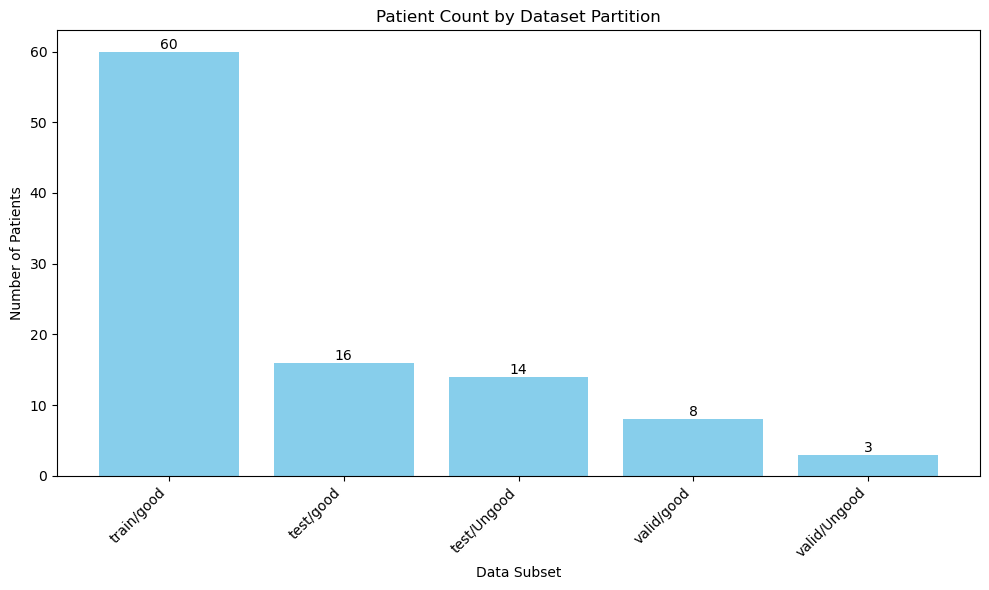

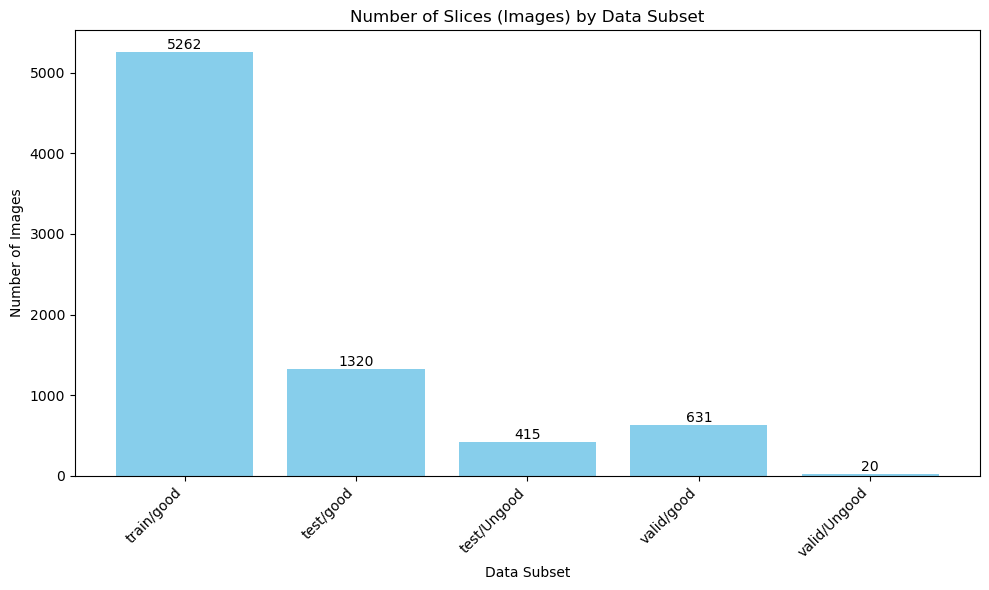

In [11]:
# Define the root directory of your dataset
dataset_path = r'C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\dataset\synth23_pelvis_v7_nifti_3ch_rep'

# Run the data analysis and plotting functions
stats_df = analyze_data_stats_by_split(dataset_path)

if stats_df is not None:
    print("Detailed Dataset Statistics:")
    print(stats_df[['split', 'category', 'Total Patients', 'Total Slices (Images)', 'Percentage Patients', 'Percentage Slices']].to_string(index=False))
    plot_stats(stats_df)

Detailed Dataset Statistics:
split category  Total Patients  Total Slices (Images)  Percentage Patients  Percentage Slices
 test   Ungood              16                    372            10.810811           3.844167
 test     good              25                   1880            16.891892          19.427509
train     good              92                   6515            62.162162          67.324584
valid   Ungood               3                     67             2.027027           0.692363
valid     good              12                    843             8.108108           8.711377


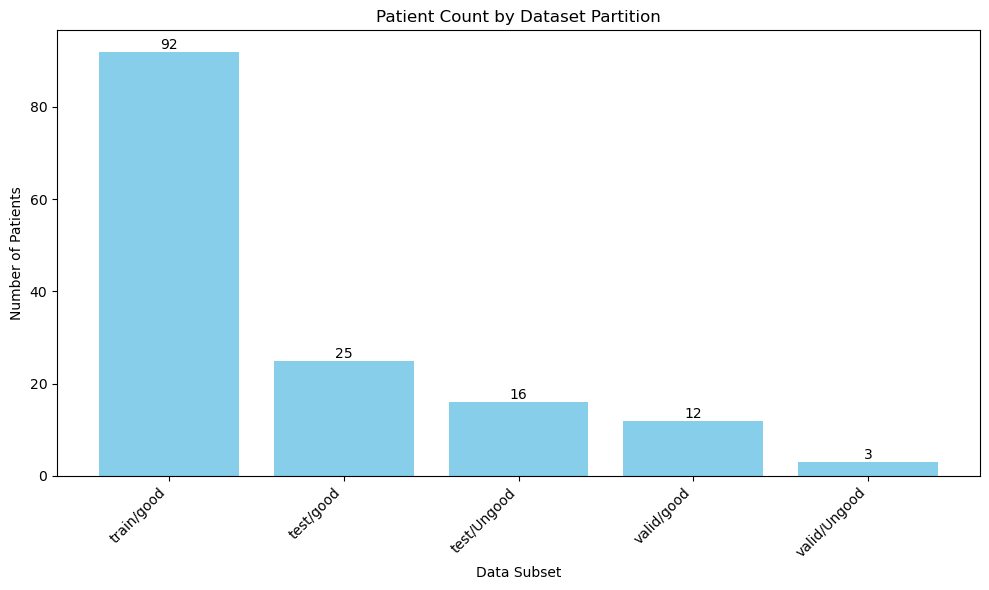

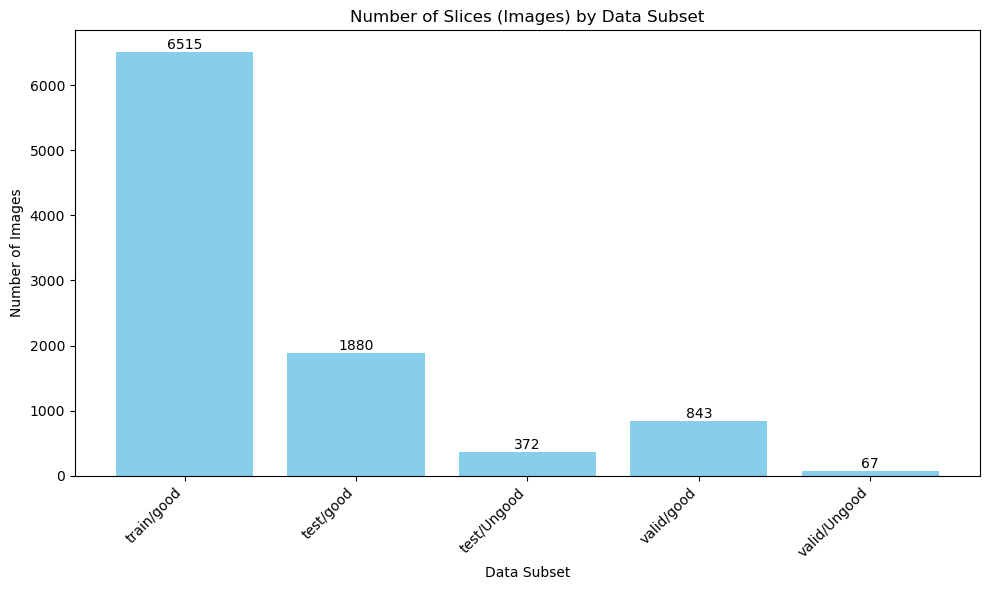

In [4]:
# Define the root directory of your dataset
dataset_path = r'C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\dataset\synth23_pelvis_v8_png'

# Run the data analysis and plotting functions
stats_df = analyze_data_stats_by_split(dataset_path)

if stats_df is not None:
    print("Detailed Dataset Statistics:")
    print(stats_df[['split', 'category', 'Total Patients', 'Total Slices (Images)', 'Percentage Patients', 'Percentage Slices']].to_string(index=False))
    plot_stats(stats_df)

Detailed Dataset Statistics:
split category  Total Patients  Total Slices (Images)  Percentage Patients  Percentage Slices
 test   Ungood              16                    372            10.810811           3.844167
 test     good              25                   1880            16.891892          19.427509
train     good              92                   6515            62.162162          67.324584
valid   Ungood               3                     67             2.027027           0.692363
valid     good              12                    843             8.108108           8.711377


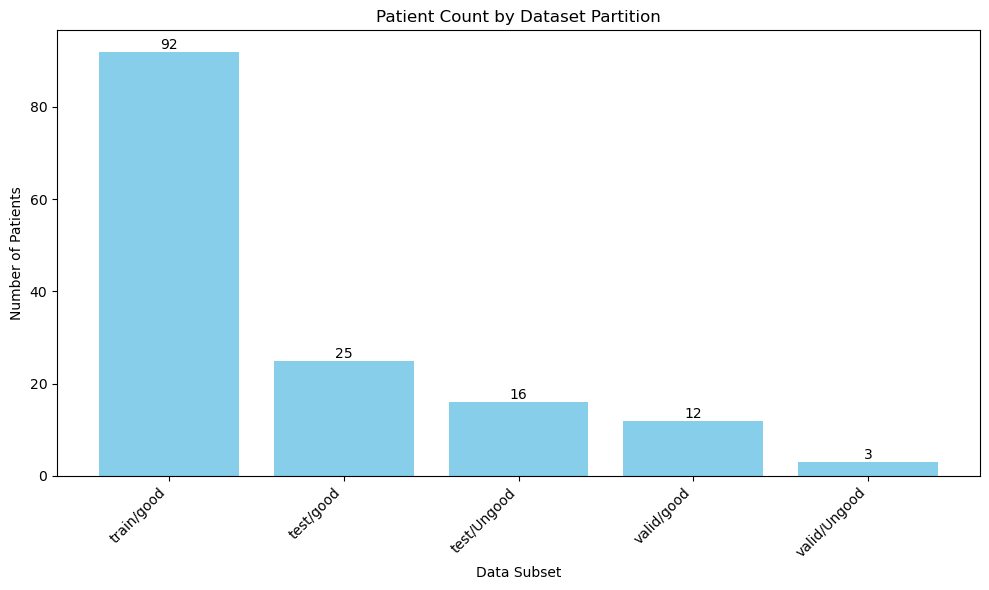

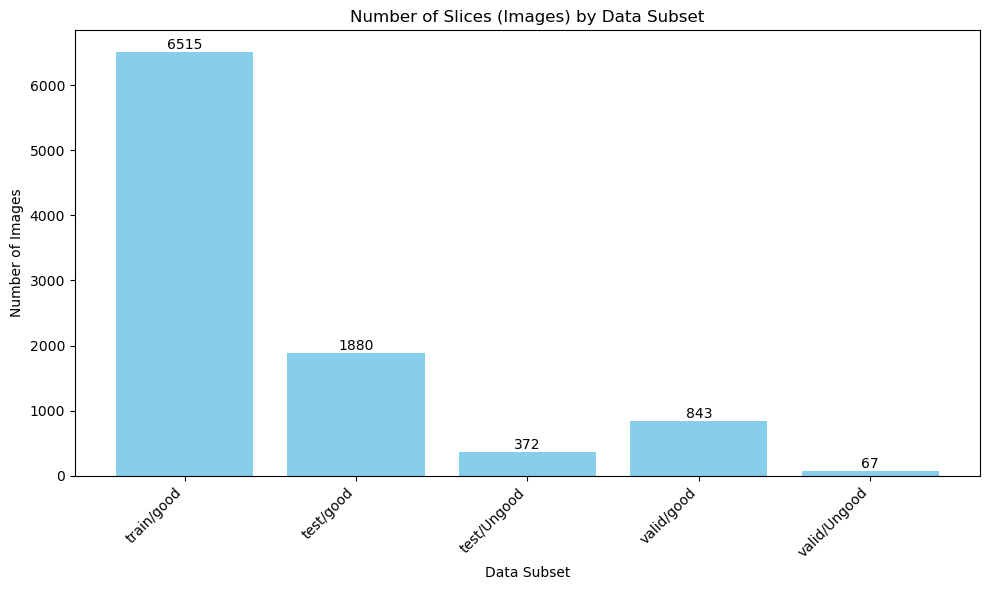

In [5]:
# Define the root directory of your dataset
dataset_path = r'C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\dataset\synth23_pelvis_v8_nifti_rep'

# Run the data analysis and plotting functions
stats_df = analyze_data_stats_by_split(dataset_path)

if stats_df is not None:
    print("Detailed Dataset Statistics:")
    print(stats_df[['split', 'category', 'Total Patients', 'Total Slices (Images)', 'Percentage Patients', 'Percentage Slices']].to_string(index=False))
    plot_stats(stats_df)

Detailed Dataset Statistics:
split category  Total Patients  Total Slices (Images)  Percentage Patients  Percentage Slices
 test   Ungood              16                    372            10.810811           3.844167
 test     good              25                   1880            16.891892          19.427509
train     good              92                   6515            62.162162          67.324584
valid   Ungood               3                     67             2.027027           0.692363
valid     good              12                    843             8.108108           8.711377


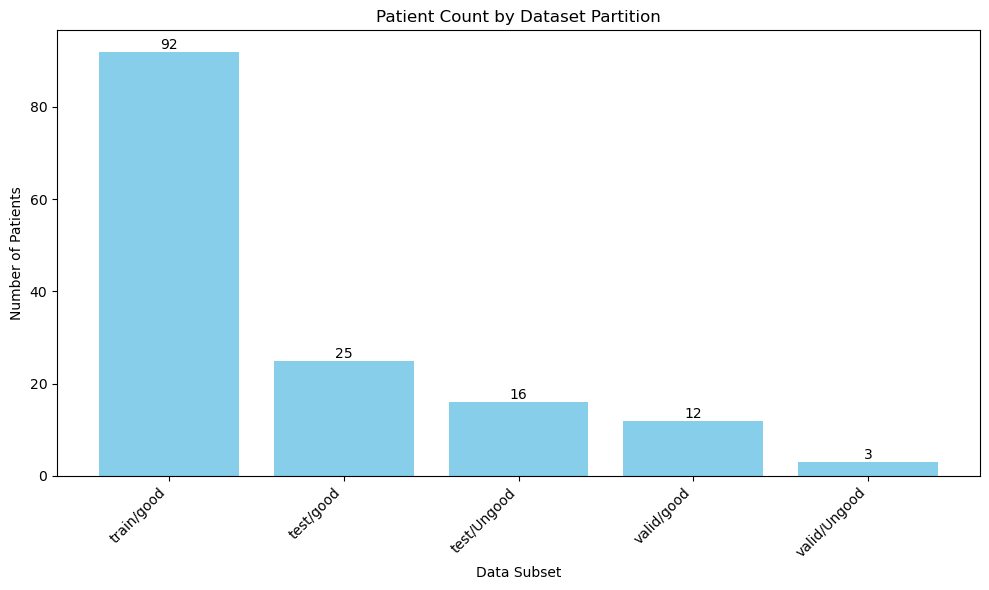

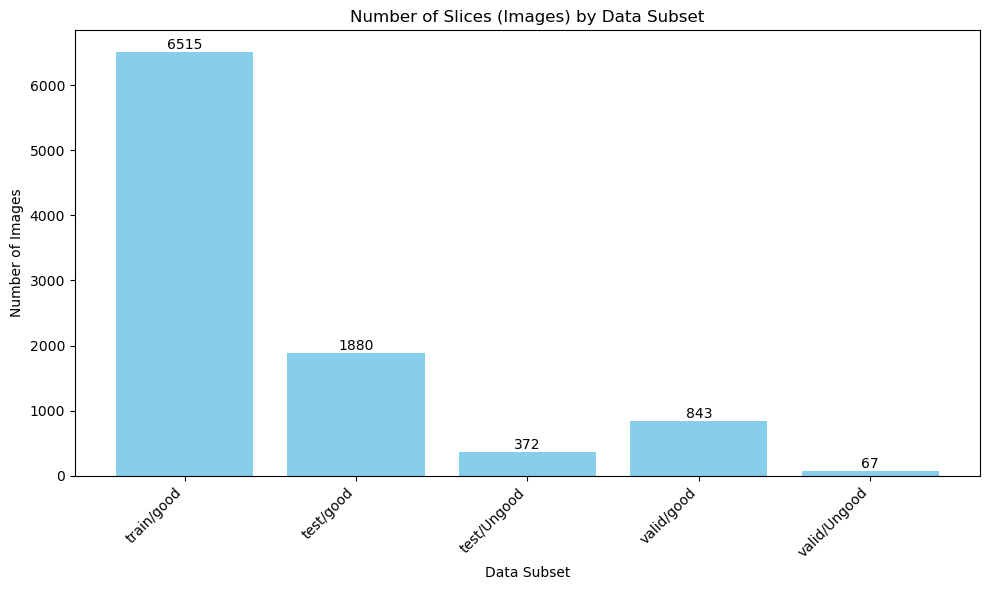

In [14]:
# Define the root directory of your dataset
dataset_path = r'C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\dataset\synth23_pelvis_v8_nifti_con'

# Run the data analysis and plotting functions
stats_df = analyze_data_stats_by_split(dataset_path)

if stats_df is not None:
    print("Detailed Dataset Statistics:")
    print(stats_df[['split', 'category', 'Total Patients', 'Total Slices (Images)', 'Percentage Patients', 'Percentage Slices']].to_string(index=False))
    plot_stats(stats_df)

In [4]:
stats_v7 = analyze_data_stats_by_split(
    r'C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\dataset\synth23_pelvis_v7_nifti_con'
)
stats_v8 = analyze_data_stats_by_split(
    r'C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\dataset\synth23_pelvis_v8_nifti_rep'
)

if stats_v7 is not None:
    stats_v7['version'] = 'Single-Center Dataset'
if stats_v8 is not None:
    stats_v8['version'] = 'Multi-Center Dataset'

cat_map = {'good': 'ID', 'Ungood': 'OOD'}
stats_v7['category'] = stats_v7['category'].replace(cat_map)
stats_v8['category'] = stats_v8['category'].replace(cat_map)

stats_both = pd.concat([stats_v7, stats_v8], ignore_index=True)


In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Global default font size (affects most text)
plt.rcParams.update({'font.size': 14}) 

def plot_grouped(stats_both, value_col, title, ylabel):
    stats_both = stats_both.copy()

    split_order = ['train', 'valid', 'test']
    cat_order = ['ID', 'OOD']
    ordered_groups = [f'{s}/{c}' for s in split_order for c in cat_order]

    stats_both['group'] = stats_both['split'] + '/' + stats_both['category']
    groups = [g for g in ordered_groups if g in stats_both['group'].unique()]
    versions = stats_both['version'].unique()

    x = np.arange(len(groups))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    all_data_values = [] # Initialize a list to track all bar heights

    for i, ver in enumerate(versions):
        subset = stats_both[stats_both['version'] == ver]

        y = []
        for g in groups:
            row = subset[subset['group'] == g]
            value = row[value_col].iloc[0] if not row.empty else 0
            y.append(value)
            all_data_values.append(value) # Add current bar height to the list

        xs = x + (i - (len(versions) - 1) / 2) * width
        bars = ax.bar(xs, y, width, label=ver)

        # Larger numeric labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=15  
            )

    # --- FIX: Increase the Y-axis limit ---
    if all_data_values:
        max_val = max(all_data_values)
        # Set the upper limit to be 10% greater than the maximum bar height
        ax.set_ylim(top=max_val * 1.10) 
    # --------------------------------------

    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=45, ha='right', fontsize=14)
    ax.set_title(title, fontsize=18)
    ax.set_xlabel('Data subset', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.legend(fontsize=14)
    plt.tight_layout()
    safe_filename = title.replace('/', '_').replace(':', '_') 
    plt.savefig(f'{safe_filename}.pdf', format='pdf')
    plt.show()

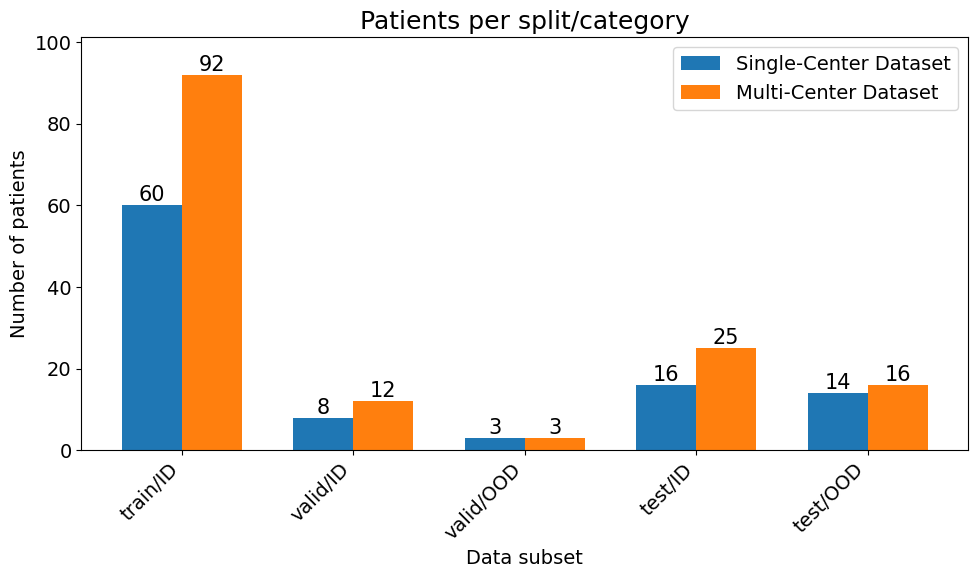

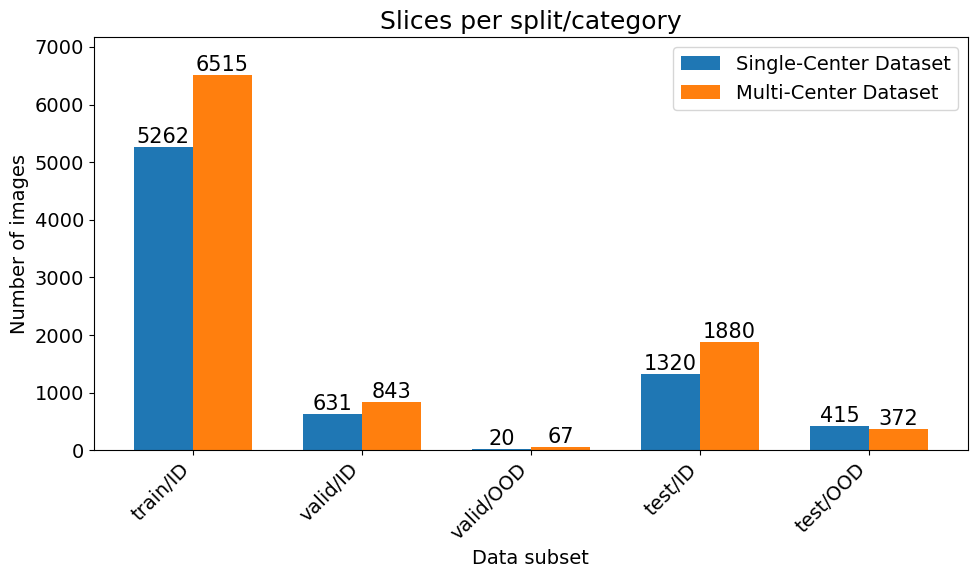

In [21]:
# usage:
plot_grouped(stats_both,
             value_col='Total Patients',
             title='Patients per split/category',
             ylabel='Number of patients')

plot_grouped(stats_both,
             value_col='Total Slices (Images)',
             title='Slices per split/category',
             ylabel='Number of images')